In [2]:
1+1

2

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [9]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [10]:
BATCH_SIZE = 64
BASELINE_EPOCHS = 8
CNN_EPOCHS = 25
VAL_SPLIT = 0.1
LEARNING_RATE = 1e-3

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [11]:
def plot_learning_curves(history, title):
    plt.figure()
    plt.plot(history.history.get("accuracy", []), label="train acc")
    plt.plot(history.history.get("val_accuracy", []), label="val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(history.history.get("loss", []), label="train loss")
    plt.plot(history.history.get("val_loss", []), label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " (Loss)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def show_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    plt.figure(figsize=(8, 8))
    disp.plot(xticks_rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def show_failure_cases(x, y_true, y_pred, labels, n=12):
    wrong_idx = np.where(y_true != y_pred)[0]
    print(f"Wrong predictions: {len(wrong_idx)} / {len(y_true)}")

    if len(wrong_idx) == 0:
        print("No failure cases to show (perfect predictions).")
        return

    n = min(n, len(wrong_idx))
    chosen = wrong_idx[:n]

    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(10, 2.8 * rows))
    for i, idx in enumerate(chosen):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(x[idx])
        plt.axis("off")
        plt.title(f"T: {labels[y_true[idx]]}\nP: {labels[y_pred[idx]]}", fontsize=10)
    plt.tight_layout()
    plt.show()



In [14]:
def build_baseline_mlp():
    # Baseline: Flatten -> Dense -> Dropout -> Dense
    model = keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(10, activation="softmax"),
        ],
        name="baseline_mlp",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_improved_cnn():
    # Augmentation layer (applied during training)
    data_augmentation = keras.Sequential(
        [
            layers.RandomFlip("horizontal", seed=SEED),
            layers.RandomRotation(0.08, seed=SEED),
            layers.RandomZoom(0.10, seed=SEED),
        ],
        name="augmentation",
    )

    # Improved CNN: Conv + BN + ReLU + Pool blocks, then Dense + Dropout
    model = keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            data_augmentation,

            layers.Conv2D(32, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(64, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(128, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),

            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(10, activation="softmax"),
        ],
        name="improved_cnn",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


TensorFlow: 2.20.0
Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


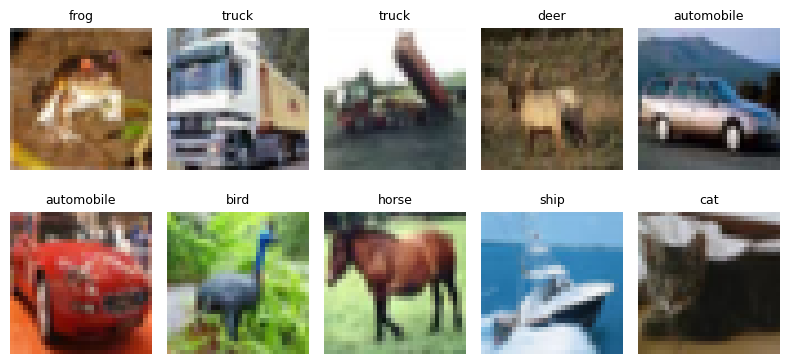

Model: "baseline_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)


Training baseline model...
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2088 - loss: 2.1832 - val_accuracy: 0.3192 - val_loss: 1.9145
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2811 - loss: 1.9385 - val_accuracy: 0.3252 - val_loss: 1.8476
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2965 - loss: 1.9079 - val_accuracy: 0.3438 - val_loss: 1.8238
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3034 - loss: 1.8877 - val_accuracy: 0.3448 - val_loss: 1.8178
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3116 - loss: 1.8735 - val_accuracy: 0.3768 - val_loss: 1.7574
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3193 - loss: 1.8524 - val_accuracy: 0.3790 - val_loss: 1.7509
Epoch 7/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3199 - loss: 1.8508 - val_accuracy: 0.3804 - val_loss: 1.7392
Epoch 8/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3209 - loss: 1.844

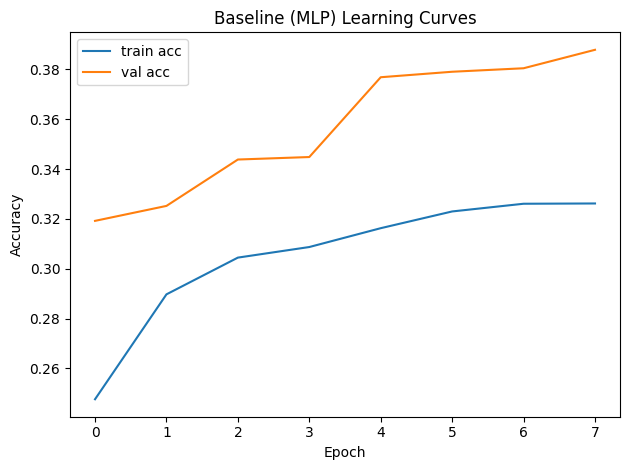

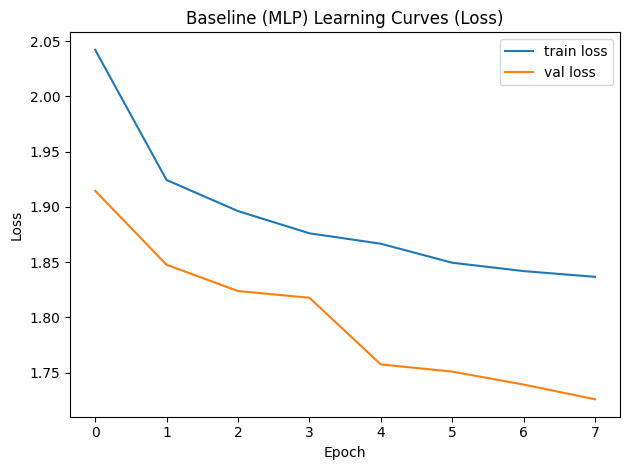

<Figure size 800x800 with 0 Axes>

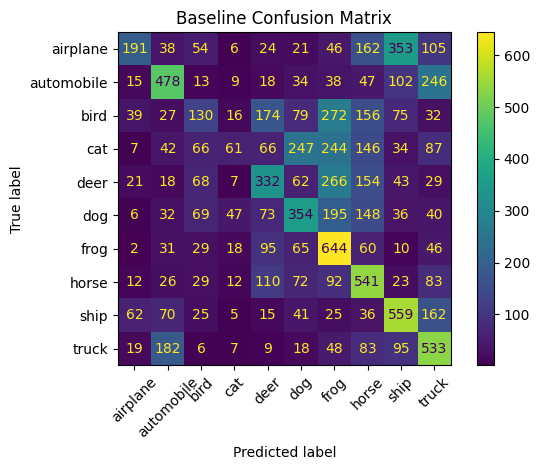


Baseline Classification Report:
              precision    recall  f1-score   support

    airplane       0.51      0.19      0.28      1000
  automobile       0.51      0.48      0.49      1000
        bird       0.27      0.13      0.17      1000
         cat       0.32      0.06      0.10      1000
        deer       0.36      0.33      0.35      1000
         dog       0.36      0.35      0.36      1000
        frog       0.34      0.64      0.45      1000
       horse       0.35      0.54      0.43      1000
        ship       0.42      0.56      0.48      1000
       truck       0.39      0.53      0.45      1000

    accuracy                           0.38     10000
   macro avg       0.38      0.38      0.36     10000
weighted avg       0.38      0.38      0.36     10000



Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)


Training improved CNN...
Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.2893 - loss: 2.0430 - val_accuracy: 0.4864 - val_loss: 1.3828 - learning_rate: 0.0010
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.4359 - loss: 1.5428 - val_accuracy: 0.4946 - val_loss: 1.3809 - learning_rate: 0.0010
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.4842 - loss: 1.4157 - val_accuracy: 0.5298 - val_loss: 1.3190 - learning_rate: 0.0010
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.5163 - loss: 1.3288 - val_accuracy: 0.6196 - val_loss: 1.0784 - learning_rate: 0.0010
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.5460 - loss: 1.2642 - val_accuracy: 0.5936 - val_loss: 1.1140 - learning_rate: 0.0010
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5646 - loss: 1.2161 - val_accuracy: 0.6568 - val_loss: 0.9799 - learning_rate: 0.0010
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/s

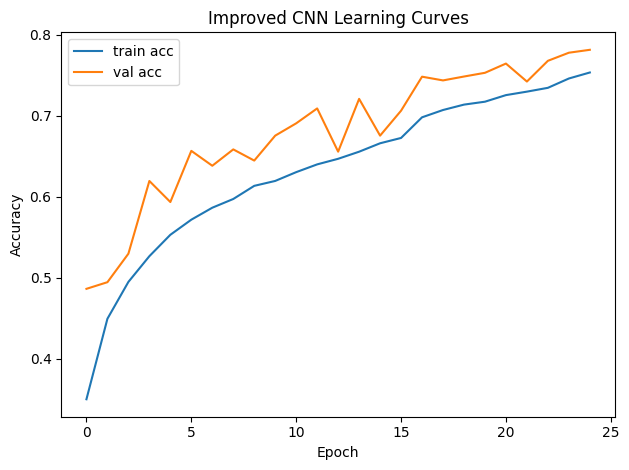

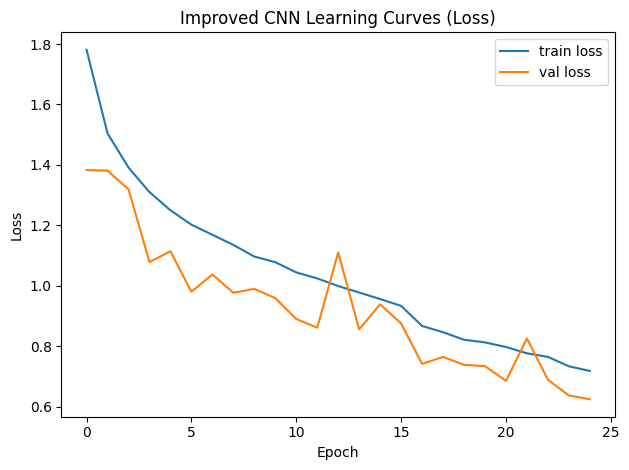

<Figure size 800x800 with 0 Axes>

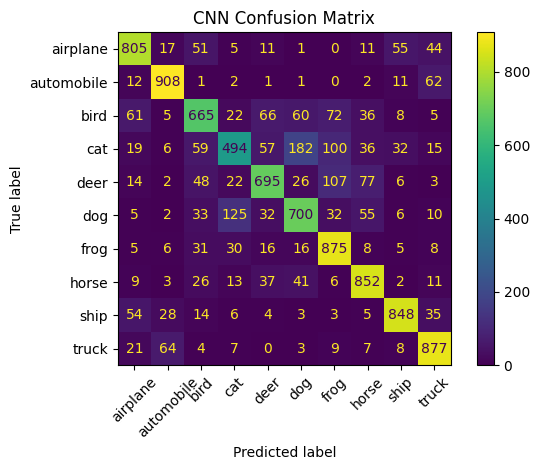


CNN Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.81      0.80      1000
  automobile       0.87      0.91      0.89      1000
        bird       0.71      0.67      0.69      1000
         cat       0.68      0.49      0.57      1000
        deer       0.76      0.69      0.72      1000
         dog       0.68      0.70      0.69      1000
        frog       0.73      0.88      0.79      1000
       horse       0.78      0.85      0.82      1000
        ship       0.86      0.85      0.86      1000
       truck       0.82      0.88      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000


=== Summary ===
Baseline Test Accuracy: 0.3823
CNN Test Accuracy     : 0.7719
Absolute improvement  : 0.3896
Wrong predictions: 2281 / 10000


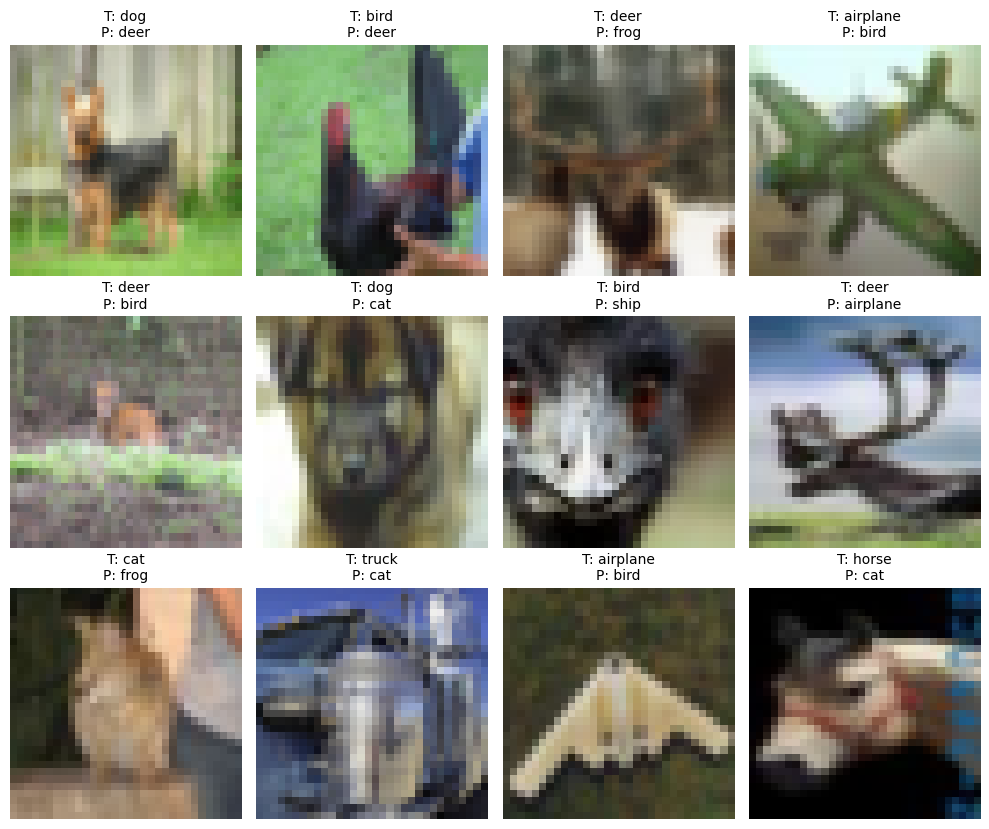

In [15]:
def main():
    print("TensorFlow:", tf.__version__)

    # Load CIFAR-10
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    y_train = y_train.squeeze()
    y_test = y_test.squeeze()

    # Normalize
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    print("Train:", x_train.shape, y_train.shape)
    print("Test :", x_test.shape, y_test.shape)

    # Quick preview
    plt.figure(figsize=(8, 4))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_train[i])
        plt.title(class_names[y_train[i]], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 1) Baseline
    # -------------------------
    baseline = build_baseline_mlp()
    baseline.summary()

    print("\nTraining baseline model...")
    hist_base = baseline.fit(
        x_train, y_train,
        epochs=BASELINE_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        verbose=1,
    )

    base_loss, base_acc = baseline.evaluate(x_test, y_test, verbose=0)
    print(f"\nBaseline Test Accuracy: {base_acc:.4f}")

    plot_learning_curves(hist_base, "Baseline (MLP) Learning Curves")

    y_pred_base = np.argmax(baseline.predict(x_test, verbose=0), axis=1)
    show_confusion_matrix(y_test, y_pred_base, class_names, "Baseline Confusion Matrix")
    print("\nBaseline Classification Report:")
    print(classification_report(y_test, y_pred_base, target_names=class_names))

    # -------------------------
    # 2) Improved CNN + Aug
    # -------------------------
    cnn = build_improved_cnn()
    cnn.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=4, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2
        ),
    ]

    print("\nTraining improved CNN...")
    hist_cnn = cnn.fit(
        x_train, y_train,
        epochs=CNN_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        callbacks=callbacks,
        verbose=1,
    )

    cnn_loss, cnn_acc = cnn.evaluate(x_test, y_test, verbose=0)
    print(f"\nCNN Test Accuracy: {cnn_acc:.4f}")

    plot_learning_curves(hist_cnn, "Improved CNN Learning Curves")

    y_pred_cnn = np.argmax(cnn.predict(x_test, verbose=0), axis=1)
    show_confusion_matrix(y_test, y_pred_cnn, class_names, "CNN Confusion Matrix")
    print("\nCNN Classification Report:")
    print(classification_report(y_test, y_pred_cnn, target_names=class_names))

    # -------------------------
    # 3) Quantitative comparison
    # -------------------------
    print("\n=== Summary ===")
    print(f"Baseline Test Accuracy: {base_acc:.4f}")
    print(f"CNN Test Accuracy     : {cnn_acc:.4f}")
    print(f"Absolute improvement  : {(cnn_acc - base_acc):.4f}")

    # -------------------------
    # 4) Failure cases
    # -------------------------
    show_failure_cases(x_test, y_test, y_pred_cnn, class_names, n=12)


if __name__ == "__main__":
    main()